# Final Report

This notebook loads the pre-trained NLP models (LDA, LSA, sLDA) from the `models/` directory and visualizes their results.

**Prerequisites:** Run the training scripts before executing this notebook:
```bash
python src/models/lda_model.py
python src/models/lsa_model.py
python src/models/slda_model.py
```

In [2]:
import os
import json
import numpy as np
import pandas as pd
import joblib
import pyLDAvis
import pyLDAvis.lda_model
from gensim import models, corpora
import tomotopy as tp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type _VocabDict has no __module__ attribute


---
## 1. Latent Dirichlet Allocation (LDA)

The LDA model was trained on the Covid-19 tweets dataset using `sklearn.LatentDirichletAllocation` with 15 topics and a `CountVectorizer` (5000 features).

Below we load the saved model and display the top keywords for each topic.

In [34]:
# Load LDA model and vectorizer
lda_model = joblib.load('../models/lda_model.pkl')
vectorizer = joblib.load('../models/lda_vectorizer.pkl')

df_covid = pd.read_csv('../data/processed/covid19_tweets_off.csv')
df_covid = df_covid.dropna(subset=['text'])
vectorized_corpus = vectorizer.transform(df_covid['text'])

print(f"Documents: {vectorized_corpus.shape[0]}, Vocabulary: {vectorized_corpus.shape[1]}")
print(f"Number of topics: {lda_model.n_components}")

Documents: 144890, Vocabulary: 5000
Number of topics: 15


In [35]:
# Show the top 5 words for each LDA topic
feature_names = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda_model.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-5:][::-1]]
    print(f"Topic {i}: {', '.join(top_words)}")

Topic 0: mask, time, wear, face, safe
Topic 1: work, use, lockdown, risk, increase
Topic 2: test, know, people, week, think
Topic 3: pandemic, high, life, student, big
Topic 4: case, new, death, report, day
Topic 5: need, amp, die, home, thing
Topic 6: good, patient, hospital, impact, month
Topic 7: school, state, government, amp, continue
Topic 8: news, come, global, million, trump
Topic 9: today, way, stop, amp, feel
Topic 10: like, year, want, virus, let
Topic 11: live, business, family, record, follow
Topic 12: world, spread, read, close, say
Topic 13: people, look, august, social, watch
Topic 14: positive, make, number, country, help


### LDA Topic Interpretation

The LDA model identifies 15 topics in the COVID-19 tweets. Here are some of the most clear and significant themes:

- **Prevention and safety:** Topic 0 (*mask, time, wear, face, safe*) focuses on personal protection measures.
- **Daily life and lockdowns:** Topics like Topic 1 (*work, lockdown, risk*) and Topic 3 (*pandemic, student, life*) capture the social and economic impact of the pandemic.
- **News and statistics:** Topic 4 (*case, new, death, report*) and Topic 14 (*positive, number, country*) reflect the daily reporting of COVID-19 figures.
- **Healthcare and hospitals:** Topic 6 (*patient, hospital, impact*) highlights the pressure on the healthcare system.
- **Politics and government:** Topic 7 (*school, government, state*) and Topic 8 (*news, global, trump*) show the political side of the crisis.

The interactive visualization below shows how these topics relate to each other. Topics that are close together share similar vocabulary.

In [36]:
# Interactive pyLDAvis visualization
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, vectorized_corpus, vectorizer, mds='tsne')
panel

PreparedData(topic_coordinates=               x           y  topics  cluster      Freq
topic                                                  
4      56.262150  -27.263222       1        1  9.303160
2      -4.037402 -201.887604       2        1  7.769632
0     -44.748920  -58.361065       3        1  7.223863
7       0.139175  -64.245201       4        1  6.987427
5      22.222916   53.793835       5        1  6.611726
10      3.793179  -22.984808       6        1  6.560861
6     -79.372871   -3.279585       7        1  6.513893
1     -35.859879  -14.931959       8        1  6.505887
14    -23.875307   62.533054       9        1  6.451385
11     -3.361889   17.949299      10        1  6.437363
8      33.980602    5.837039      11        1  6.182214
3      64.646118   34.546677      12        1  6.065456
9     -46.860893   28.726454      13        1  5.859101
13      2.029503  102.024673      14        1  5.819888
12     43.705605  -67.219185      15        1  5.708146, topic_info=            Term          Freq         Total Category  logprob  loglift
648         case  13230.000000  13230.000000  Default  30.0000  30.0000
2989         new  11018.000000  11018.000000  Default  29.0000  29.0000
3242      people   8996.000000   8996.000000  Default  28.0000  28.0000
1136       death   6660.000000   6660.000000  Default  27.0000  27.0000
4470        test   6186.000000   6186.000000  Default  26.0000  26.0000
...          ...           ...           ...      ...      ...      ...
2549  leadership    367.956603    368.885346  Topic15  -4.9800   2.8608
1178       delay    351.599359    352.528102  Topic15  -5.0255   2.8606
3134     outside    339.986095    340.914838  Topic15  -5.0591   2.8605
3920         say   1158.274957   5639.202311  Topic15  -3.8333   1.2805
177          amp    854.519158  10543.455807  Topic15  -4.1375   0.3506

[532 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
5         5  0.998196       able
25       14  0.997440     access
30       14  0.998152     accord
44        5  0.998751        act
46       10  0.998734     action
...     ...       ...        ...
4968      9  0.997414      wrong
4977      6  0.999702       year
4983      6  0.998256        yes
4984      2  0.999355  yesterday
4989      2  0.998981      young

[512 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 3, 1, 8, 6, 11, 7, 2, 15, 12, 9, 4, 10, 14, 13])

---
## 2. Latent Semantic Analysis (LSA)

The LSA model was trained using `gensim.LsiModel` on a TF-IDF representation of the same corpus. Three configurations were compared (5, 20, 40 topics) and the best was selected by U-Mass coherence.

Unlike LDA, LSA can produce **negative weights** for words. A negative weight means that the word is *anti-correlated* with that topic: when the word appears, the topic is less likely.

In [37]:
# Load LSA model and dictionary
lsa_model = models.LsiModel.load('../models/lsa_model.gensim')
dictionary = corpora.Dictionary.load('../models/lsa_dictionary.gensim')

print(f"Number of topics: {lsa_model.num_topics}")
print(f"Dictionary size: {len(dictionary)}")

# Display top keywords per topic (using structured output to handle negative weights)
topics = lsa_model.show_topics(num_topics=-1, num_words=5, formatted=False)
print(f"\nTop 5 keywords for each of the {len(topics)} topics:\n")
for topic_id, words in topics:
    top_words = ', '.join([f'{word} ({weight:+.3f})' for word, weight in words])
    print(f"  Topic {topic_id}: {top_words}")

Number of topics: 20
Dictionary size: 63078

Top 5 keywords for each of the 20 topics:

  Topic 0: case (+0.574), new (+0.401), death (+0.303), report (+0.268), total (+0.236)
  Topic 1: people (+0.260), case (-0.243), mask (+0.219), get (+0.202), wear (+0.171)
  Topic 2: test (-0.630), positive (-0.426), mask (+0.391), wear (+0.309), new (+0.196)
  Topic 3: mask (-0.568), wear (-0.461), test (-0.367), positive (-0.285), pandemic (+0.144)
  Topic 4: death (-0.602), new (+0.468), people (-0.334), die (-0.217), toll (-0.152)
  Topic 5: people (-0.651), amp (+0.407), death (+0.290), die (-0.258), new (-0.165)
  Topic 6: day (-0.531), new (+0.336), death (+0.278), case (-0.243), amp (+0.238)
  Topic 7: amp (+0.480), death (-0.405), new (-0.349), case (+0.303), total (+0.235)
  Topic 8: get (+0.428), amp (-0.308), total (+0.304), day (-0.291), people (-0.260)
  Topic 9: pandemic (+0.425), amp (-0.383), get (-0.371), day (-0.228), global (+0.212)
  Topic 10: need (+0.520), hour (+0.320), las

### LSA Topic Interpretation

The LSA model uses a different mathematical approach (singular value decomposition) and produces 20 topics. Because it can have **negative weights**, it often captures *contrasts* between different themes.

Here are the most interesting patterns from the first few topics:

- **General COVID talk:** Topic 0 has only positive weights (*case, new, death, report*). It represents the most common words across the entire dataset.
- **Masks vs. Testing:** Topic 2 creates a contrast between *mask/wear* (positive) and *test/positive* (negative). This separates tweets about prevention from tweets about testing.
- **Death toll vs. New updates:** Topic 4 contrasts *death/die* (negative) with *new* (positive), separating mortality discussions from general news updates.
- **Vaccines vs. Daily needs:** Topic 11 separates *vaccine* (negative) from *need/day* (positive).

The later topics become more noisy and less interpretable, which is common in LSA.

---
## 3. Supervised LDA (sLDA)

The sLDA model was trained on the **suspicious tweets** dataset using `tomotopy.SLDAModel`. Unlike standard LDA, sLDA jointly models topics and a **binary label** (suspicious vs. neutral). The optimal number of topics and classification threshold were selected by grid search on F1-score.

This means the model learns topics that are specifically useful for predicting whether a tweet is suspicious or not.

In [3]:
# Load sLDA model
slda_model = tp.SLDAModel.load('../models/slda_model.bin')

print(f"Number of topics (k): {slda_model.k}")
print(f"Number of documents used for training: {len(slda_model.docs)}")
print(f"Vocabulary size: {len(slda_model.used_vocabs)}")

Number of topics (k): 80
Number of documents used for training: 36475
Vocabulary size: 31777


In [4]:
# Load and display saved performance metrics
with open('../models/slda_metrics.json', 'r') as f:
    metrics = json.load(f)

print("sLDA Classification Performance (Test Set)")
print("=" * 42)
print(f"Optimal number of topics: {metrics['optimal_topics']}")
print(f"Optimal threshold:        {metrics['optimal_threshold']}")
print(f"Accuracy:                 {metrics['accuracy']:.4f}")
print(f"F1-score:                 {metrics['f1_score']:.4f}")
print(f"Precision:                {metrics['precision']:.4f}")
print(f"Recall:                   {metrics['recall']:.4f}")

sLDA Classification Performance (Test Set)
Optimal number of topics: 80
Optimal threshold:        0.85
Accuracy:                 0.9545
F1-score:                 0.9540
Precision:                0.9711
Recall:                   0.9773


In [5]:
# Display top words per topic
print(f"Top 10 keywords for each of the {slda_model.k} topics:\n")
for k in range(slda_model.k):
    top_words = slda_model.get_topic_words(k, top_n=10)
    words_str = ', '.join([f'{word} ({prob:.3f})' for word, prob in top_words])
    print(f"  Topic {k}: {words_str}")

Top 10 keywords for each of the 80 topics:

  Topic 0: hurt (0.067), bad (0.030), feel (0.025), head (0.025), sore (0.022), throat (0.021), still (0.016), eye (0.015), tooth (0.013), ache (0.012)
  Topic 1: lol (0.059), jus (0.023), tha (0.015), wit (0.015), sum (0.014), blah (0.011), thee (0.011), later (0.010), bak (0.009), sniff (0.009)
  Topic 2: he (0.146), s (0.146), music (0.020), amp (0.019), download (0.018), cheer (0.018), free (0.016), fun (0.016), suggest (0.013), project (0.012)
  Topic 3: like (0.165), feel (0.069), look (0.057), good (0.042), sound (0.039), really (0.028), fun (0.025), though (0.018), nice (0.017), way (0.013)
  Topic 4: study (0.068), test (0.041), exam (0.039), class (0.036), tomorrow (0.025), french (0.019), math (0.019), english (0.017), project (0.014), fail (0.013)
  Topic 5: thank (0.071), great (0.063), show (0.044), awesome (0.034), appreciate (0.023), tonight (0.022), glad (0.017), sam (0.016), share (0.015), hear (0.013)
  Topic 6: butter (0.0

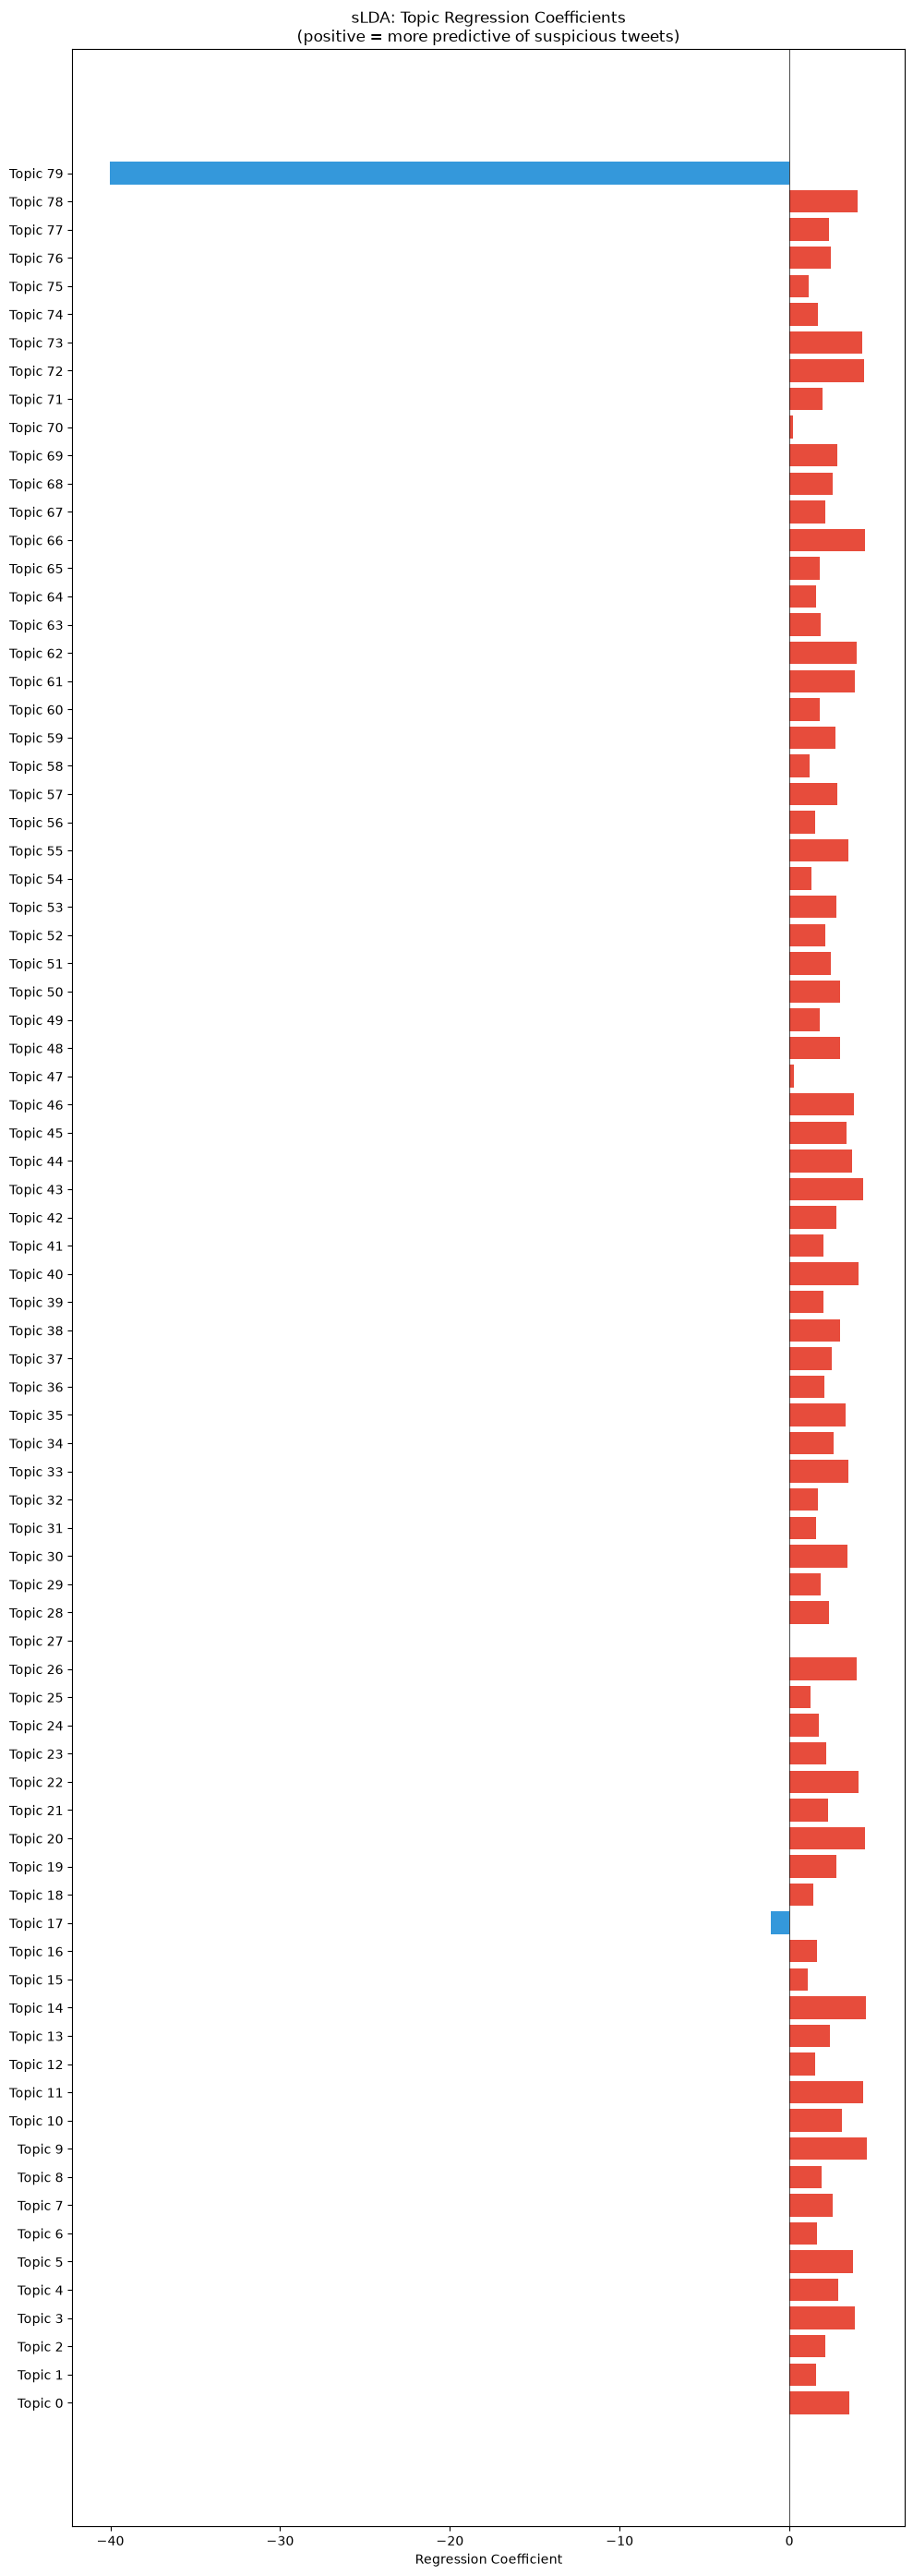

In [6]:
# Visualize regression coefficients - shows which topics are most predictive
# of the supervision variable (suspicious = 1)
coef = slda_model.get_regression_coef(0)
topic_labels = [f'Topic {i}' for i in range(slda_model.k)]

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef]

fig, ax = plt.subplots(figsize=(10, max(5, slda_model.k * 0.35)))
ax.barh(topic_labels, coef, color=colors)
ax.set_xlabel('Regression Coefficient')
ax.set_title('sLDA: Topic Regression Coefficients\n(positive = more predictive of suspicious tweets)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()